In [ ]:
%pip install numpy tensorflow

In [ ]:
import re
import os
import zipfile
import sys
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import ops, layers



Configuration: nested dictionaries containing parameters

In [ ]:
configuration = {
    "network" : {
        "input_shape" : (128, 128, 1),
        "num_classes" : 62,
        "convolution" : {
            "initial_filters" : 32,
            "num_blocks" : 5, #every block contains a kernel_size conv, a 2x2 maxpooling, and optionally a batchnorm
            "kernel_size" : 3,
            "filter_multiplier" : 2,
            "use_batchnorm" : True
        },
        "dense" : {
            "num_layers" : 1,
            "neuron_per_layer" : [512],
            "use_batchnorm" : False,
            "dropout_rate" : 0.4
        }
    },
    "training" : {
        "epochs" : 60,
        "batch_size" : 128,
        "learning_rate" : 0.003,
        "validation_split" : 0.2,
        "holdout_split" : 0.1,
        "early_stopping" : True,
        "patience" : 10,
        "checkpoint_path" : "best_model.h5"
    },
    "evaluation" : {
        "batch_size" : 128,
        "verbose" : 1
    }
}

Unzip helper, faster than loading uncompressed folders from drive

In [ ]:
def unzip_file(zip_path, output_dir):
    """
    Extracts a ZIP file to a specified directory.

    Args:
        zip_path (str): Path to the source ZIP file.
        output_dir (str): Path to the destination directory.
    """
    # Check if the zip file exists
    if not os.path.exists(zip_path):
        print(f"Error: The file '{zip_path}' does not exist.")
        return

    # Check if the file is actually a zip file
    if not zipfile.is_zipfile(zip_path):
        print(f"Error: The file '{zip_path}' is not a valid ZIP file.")
        return

    # Create the output directory if it doesn't exist
    if not os.path.exists(output_dir):
        try:
            os.makedirs(output_dir)
            print(f"Created directory: {output_dir}")
        except OSError as e:
            print(f"Error: Could not create directory '{output_dir}'. Reason: {e}")
            return

    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Get the total number of files for a simple progress indication
            file_count = len(zip_ref.infolist())
            print(f"Extracting {file_count} files to '{output_dir}'...")

            # Extract all files
            zip_ref.extractall(output_dir)

            print("Extraction complete successfully.")

    except zipfile.BadZipFile:
        print("Error: The file is a corrupt ZIP file.")
    except PermissionError:
        print("Error: Permission denied. Check your write access to the output folder.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Folder parser: takes the root train folder and creates image + label pairs

In [ ]:
class FolderParser():
    root_folder = None

    def __init__(self, root_folder):
        self.root_folder = root_folder

    def class_from_filename(self, filename: str):
        # Pattern for training data: imgXXX-YYY.png
        train_pattern = r'img(\d+)'
        match = re.search(train_pattern, filename)

        if match:
            return int(match.group(1)) - 1
        else:
            return -1 # Fallback for unmatchable files

    def traverse_from_root(self):
        file_paths = []
        labels = []
        count = 0
        for root, dirs, files in os.walk(self.root_folder):
            for file in files:
                classof = self.class_from_filename(str(file))
                if classof != -1: # Only include files for which a class could be extracted
                    full_path = os.path.join(root, file)
                    file_paths.append(full_path)
                    labels.append(classof)
                    count += 1
        print(f"Collected {count} file paths and labels, done!")
        return np.array(file_paths), np.array(labels)

Labeled image preprocessing

In [ ]:
def preprocess_image(file_path, label):
    """
    Reads an image from a file path, preprocesses it, and returns the image and label.
    """
    img = tf.io.read_file(file_path)
    img = tf.io.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32) # Convert to float32 (auto scaling)
    img = tf.image.resize(img, (128, 128)) # Resize


    return img, label

Processing the final test images

In [ ]:
def preprocess_unlabeled(file_path):
    """
    Loads and preprocesses an image without a label.
    Returns (image, file_path) so you can track which file is being predicted.
    """
    # 1. Read the file
    img = tf.io.read_file(file_path)

    # 2. Decode (Ensure 3 channels for RGB or 1 for Grayscale)
    # Adjust channels=3 or channels=1 to match your model input
    img = tf.io.decode_png(img, channels=1)

    # 3. Convert to float32 (0 to 1 range implied by convert_image_dtype)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # 4. Resize to match your model's expected input
    img = tf.image.resize(img, (128, 128))

    # Return both the processed image AND the path
    return img, file_path

def create_prediction_dataset(folder_path, batch_size=32):
    """
    Creates a dataset from a folder of images.
    """
    # 1. Get all file paths matching the pattern
    # list_files is perfect for this. shuffle=False is CRITICAL for inference.
    dataset = tf.data.Dataset.list_files(f"{folder_path}/*", shuffle=False)

    # 2. Map the preprocessing function
    dataset = dataset.map(preprocess_unlabeled, num_parallel_calls=tf.data.AUTOTUNE)

    # 3. Batch the data
    dataset = dataset.batch(batch_size)

    # 4. Prefetch for performance
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

Training + validation dataset builder

In [ ]:
def create_tf_dataset(file_paths, labels, config, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    if is_training:
        buffer_size = min(len(file_paths), 5000)
        dataset = dataset.shuffle(buffer_size=buffer_size)

    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(
        config["training"]["batch_size"],
        drop_remainder=is_training
    )

    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [ ]:

def build_cnn_architecture(config):

    input_shape = config["network"]["input_shape"]
    num_classes = config["network"]["num_classes"]

    conv_cfg = config["network"]["convolution"]
    dense_cfg = config["network"]["dense"]

    inputs = keras.Input(shape=input_shape)

    # ---- DATA AUGMENTATION LAYERS -----
    x = layers.RandomZoom(
        height_factor=(-0.1, 0.1),
        width_factor=(-0.1, 0.1),
        fill_mode='constant',
        fill_value=1.0
    )(inputs)

    x = layers.RandomRotation(
        factor=(-0.03, 0.03),
        fill_mode='constant',
        fill_value=1.0
    )(x)



    # ----- CONV BLOCKS -----
    filters = conv_cfg["initial_filters"]
    for i in range(conv_cfg["num_blocks"]):
        x = layers.Conv2D(
            filters=filters,
            kernel_size=(conv_cfg["kernel_size"], conv_cfg["kernel_size"]),
            padding="same"
        )(x)

        if conv_cfg.get("use_batchnorm", False):
            x = layers.BatchNormalization()(x)

        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2, 2))(x)

        filters *= conv_cfg["filter_multiplier"]

    # ----- FLATTEN -----
    x = layers.Flatten()(x)

    # ----- DENSE LAYERS -----
    for i in range(dense_cfg["num_layers"]):
        x = layers.Dense(dense_cfg["neuron_per_layer"][i])(x)

        if dense_cfg.get("use_batchnorm", False):
            x = layers.BatchNormalization()(x)

        x = layers.ReLU()(x)

        if dense_cfg.get("dropout_rate", 0) > 0:
            x = layers.Dropout(dense_cfg["dropout_rate"])(x)

    # ----- OUTPUT -----
    outputs = layers.Dense(num_classes)(x)

    return keras.Model(inputs, outputs, name="ocr_cnn")


In [ ]:
def train_model(model, config, train_dataset, val_dataset):

    # --- Compile (training hyperparams come from config) ---
    train_cfg = config["training"]

    optimizer = tf.keras.optimizers.Adam(train_cfg["learning_rate"])

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    # --- Callbacks ---
    callbacks = []
    if train_cfg.get("early_stopping", True):
        callbacks.append(tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=train_cfg.get("patience", 5),
            restore_best_weights=True
        ))

    if train_cfg.get("checkpoint_path", None):
        callbacks.append(tf.keras.callbacks.ModelCheckpoint(
            train_cfg["checkpoint_path"],
            save_best_only=True,
            initial_value_threshold=0.8
        ))


    callbacks.append(tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # Multiply LR by 0.5
        patience=5,       # Wait 5 epochs
        min_lr=1e-6,      # Don't go below this
        verbose=1
    ))

    # --- Actual training ---
    history = model.fit(
        train_dataset, # Use train_dataset
        epochs=train_cfg["epochs"],
        validation_data=val_dataset,
        callbacks=callbacks,
        shuffle=True
    )

    return model, history


In [ ]:

def evaluate_model(model, test_dataset, config):
    """
    Evaluate a trained model on a separate test dataset.

    Parameters
    ----------
    model : tf.keras.Model
        A fully trained and compiled model.

    test_dataset : tf.data.Dataset
        A tf.data.Dataset containing test images and labels.

    config : dict
        Full project configuration. Only the "evaluation" block is used.

    Returns
    -------
    metrics : dict
        A dictionary containing loss, accuracy és egyéb metrikák.
    """

    eval_cfg = config.get("evaluation", {})

    batch_size = eval_cfg.get("batch_size", 64)
    verbose = eval_cfg.get("verbose", 1)

    # Evaluate the model
    results = model.evaluate(
        test_dataset,
        batch_size=batch_size,
        verbose=verbose
    )

    # Convert results (list) to a named dictionary
    # Keras returns: [loss, accuracy] by default
    metric_names = model.metrics_names
    metrics = dict(zip(metric_names, results))

    if verbose:
        print("\n=== Evaluation Results ===")
        for name, value in metrics.items():
            print(f"{name}: {value:.4f}")

    return metrics


Defining stuff is complete, run calls below

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Folder uncompressing

In [ ]:
train1 = "/content/Train1.zip"
train2 = "/content/Train2.zip"
# test = "/path/to/your/TestData.zip"

unzip_file(train1, "/content/traindata")
unzip_file(train2, "/content/traindata")
# unzip_file(test, "/content/testdata")



Created directory: /content/traindata
Extracting 26331 files to '/content/traindata'...
Extraction complete successfully.
Extracting 26903 files to '/content/traindata'...
Extraction complete successfully.


Parser creates filename and label lists

In [ ]:
parser = FolderParser("/content/traindata")
image_files, labels = parser.traverse_from_root()

Collected 53172 file paths and labels, done!


Holdout + validation split

In [ ]:
np.random.seed(69)  # For reproducibility

# Separate holdout set
holdout_split_ratio = configuration['training']['holdout_split']
num_samples = len(image_files)
num_holdout_samples = int(num_samples * holdout_split_ratio)
num_train_val_samples = num_samples - num_holdout_samples

#shuffle indices
indices = np.arange(num_samples)
np.random.shuffle(indices)

holdout_indices = indices[:num_holdout_samples]
train_val_indices = indices[num_holdout_samples:]

holdout_file_paths = image_files[holdout_indices]
holdout_labels = labels[holdout_indices]

# Split data into training and validation sets
validation_split_ratio = configuration['training']['validation_split']
num_samples = len(train_val_indices)
num_val_samples = int(num_samples * validation_split_ratio)
num_train_samples = num_samples - num_val_samples

# Shuffle train_val indices
indices = np.arange(num_samples)
np.random.shuffle(indices)

val_indices = indices[:num_val_samples]
train_indices = indices[num_val_samples:]

train_file_paths = image_files[train_val_indices][train_indices]
train_labels = labels[train_val_indices][train_indices]
val_file_paths = image_files[train_val_indices][val_indices]
val_labels = labels[train_val_indices][val_indices]

# Create tf.data.Dataset objects
train_dataset = create_tf_dataset(train_file_paths, train_labels, configuration, is_training=True)
val_dataset = create_tf_dataset(val_file_paths, val_labels, configuration, is_training=False)
holdout_dataset = create_tf_dataset(holdout_file_paths, holdout_labels, configuration, is_training=False)

Build model

In [ ]:
model = build_cnn_architecture(configuration)
model.summary()

Model: "ocr_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 512)      │             

 Total params: 5,798,590 (22.12 MB)

 Trainable params: 5,796,606 (22.11 MB)

 Non-trainable params: 1,984 (7.75 KB)

Train or load model

In [ ]:
# model_path = "saved_models/first_best_92p/best_model.h5"
# history_path = "saved_models/first_best_92p/history.json"

#load and continue training the model
# model, history = keras.models.load_model(model_path), JSON(history_path)

trained_model, history = train_model(model, configuration, train_dataset, val_dataset)

Epoch 1/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 76s 192ms/step - accuracy: 0.0515 - loss: 6.2462 - val_accuracy: 0.0174 - val_loss: 5.7599 - learning_rate: 0.0030
Epoch 2/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 186ms/step - accuracy: 0.1644 - loss: 2.9010 - val_accuracy: 0.4341 - val_loss: 2.0108 - learning_rate: 0.0030
Epoch 3/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 83s 188ms/step - accuracy: 0.2179 - loss: 2.5910 - val_accuracy: 0.6076 - val_loss: 1.5385 - learning_rate: 0.0030
Epoch 4/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.2499 - loss: 2.4510 - val_accuracy: 0.6503 - val_loss: 1.4517 - learning_rate: 0.0030
Epoch 5/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.2716 - loss: 2.3529 - val_accuracy: 0.6448 - val_loss: 1.2110 - learning_rate: 0.0030
Epoch 6/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.2762 - loss: 2.3316 - val_accuracy: 0.6112 - val_loss: 1.3563 - learning_rate: 0.0030
Epoch 7/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 189ms/step - accuracy: 0.2

299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 191ms/step - accuracy: 0.3533 - loss: 2.0228 - val_accuracy: 0.7964 - val_loss: 0.7280 - learning_rate: 0.0030
Epoch 16/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3677 - loss: 1.9531

299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 191ms/step - accuracy: 0.3677 - loss: 1.9531 - val_accuracy: 0.8104 - val_loss: 0.7079 - learning_rate: 0.0030
Epoch 17/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 190ms/step - accuracy: 0.3890 - loss: 1.8870 - val_accuracy: 0.7440 - val_loss: 0.9664 - learning_rate: 0.0030
Epoch 18/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 190ms/step - accuracy: 0.4342 - loss: 1.6985 - val_accuracy: 0.7622 - val_loss: 0.8300 - learning_rate: 0.0030
Epoch 19/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.4841 - loss: 1.5576

299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 190ms/step - accuracy: 0.4842 - loss: 1.5575 - val_accuracy: 0.8153 - val_loss: 0.4992 - learning_rate: 0.0030
Epoch 20/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.4908 - loss: 1.5147 - val_accuracy: 0.7859 - val_loss: 0.7246 - learning_rate: 0.0030
Epoch 21/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5037 - loss: 1.4872

299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 191ms/step - accuracy: 0.5038 - loss: 1.4871 - val_accuracy: 0.8226 - val_loss: 0.4985 - learning_rate: 0.0030
Epoch 22/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5244 - loss: 1.4189

...

299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8199 - loss: 0.4453 - val_accuracy: 0.8932 - val_loss: 0.2426 - learning_rate: 0.0030
Epoch 45/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8263 - loss: 0.4250

299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8263 - loss: 0.4250 - val_accuracy: 0.8884 - val_loss: 0.2353 - learning_rate: 0.0030
Epoch 46/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 187ms/step - accuracy: 0.8269 - loss: 0.4255 - val_accuracy: 0.8665 - val_loss: 0.3102 - learning_rate: 0.0030
Epoch 47/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8325 - loss: 0.4067 - val_accuracy: 0.8926 - val_loss: 0.2356 - learning_rate: 0.0030
Epoch 48/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 187ms/step - accuracy: 0.8357 - loss: 0.4015 - val_accuracy: 0.8899 - val_loss: 0.2450 - learning_rate: 0.0030
Epoch 49/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 58s 195ms/step - accuracy: 0.8383 - loss: 0.3860 - val_accuracy: 0.8968 - val_loss: 0.2372 - learning_rate: 0.0030
Epoch 50/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8471 - loss: 0.3632

299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 190ms/step - accuracy: 0.8471 - loss: 0.3631 - val_accuracy: 0.9046 - val_loss: 0.2270 - learning_rate: 0.0030
Epoch 51/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8516 - loss: 0.3577 - val_accuracy: 0.8888 - val_loss: 0.2430 - learning_rate: 0.0030
Epoch 52/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 59s 197ms/step - accuracy: 0.8550 - loss: 0.3484 - val_accuracy: 0.8850 - val_loss: 0.2614 - learning_rate: 0.0030
Epoch 53/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8593 - loss: 0.3335

299/299 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.8593 - loss: 0.3335 - val_accuracy: 0.9080 - val_loss: 0.2159 - learning_rate: 0.0030
Epoch 54/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8633 - loss: 0.3261 - val_accuracy: 0.8942 - val_loss: 0.2414 - learning_rate: 0.0030
Epoch 55/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8653 - loss: 0.3243 - val_accuracy: 0.9046 - val_loss: 0.2161 - learning_rate: 0.0030
Epoch 56/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8663 - loss: 0.3186

299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8663 - loss: 0.3185 - val_accuracy: 0.9026 - val_loss: 0.2153 - learning_rate: 0.0030
Epoch 57/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8731 - loss: 0.2971 - val_accuracy: 0.9016 - val_loss: 0.2218 - learning_rate: 0.0030
Epoch 58/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8671 - loss: 0.3065 - val_accuracy: 0.9011 - val_loss: 0.2208 - learning_rate: 0.0030
Epoch 59/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8767 - loss: 0.2870 - val_accuracy: 0.9099 - val_loss: 0.2228 - learning_rate: 0.0030
Epoch 60/60
299/299 ━━━━━━━━━━━━━━━━━━━━ 56s 188ms/step - accuracy: 0.8822 - loss: 0.2838 - val_accuracy: 0.9018 - val_loss: 0.2250 - learning_rate: 0.0030


In [ ]:
# save history
import json

with open('history.json', 'w') as f:
    json.dump(history.history, f, indent=4)

Display accuracy and loss graphs

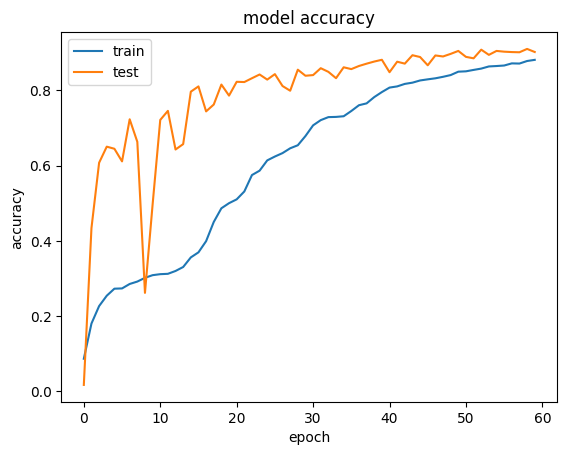

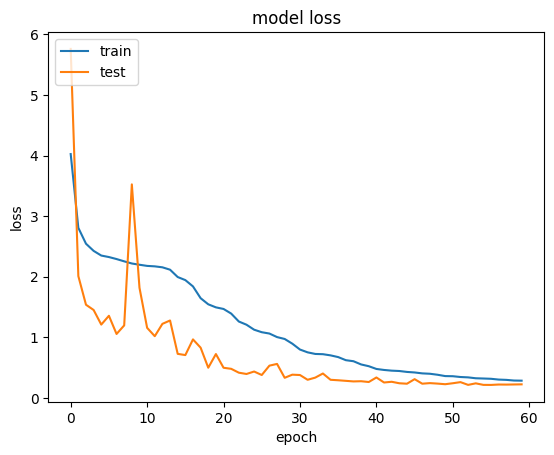

In [ ]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Evaluate model on hold-out dataset

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9080 - loss: 0.2013

=== Evaluation Results ===
loss: 0.2039
compile_metrics: 0.9075

=== Holdout Set Evaluation ===
loss: 0.2039
compile_metrics: 0.9075
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 


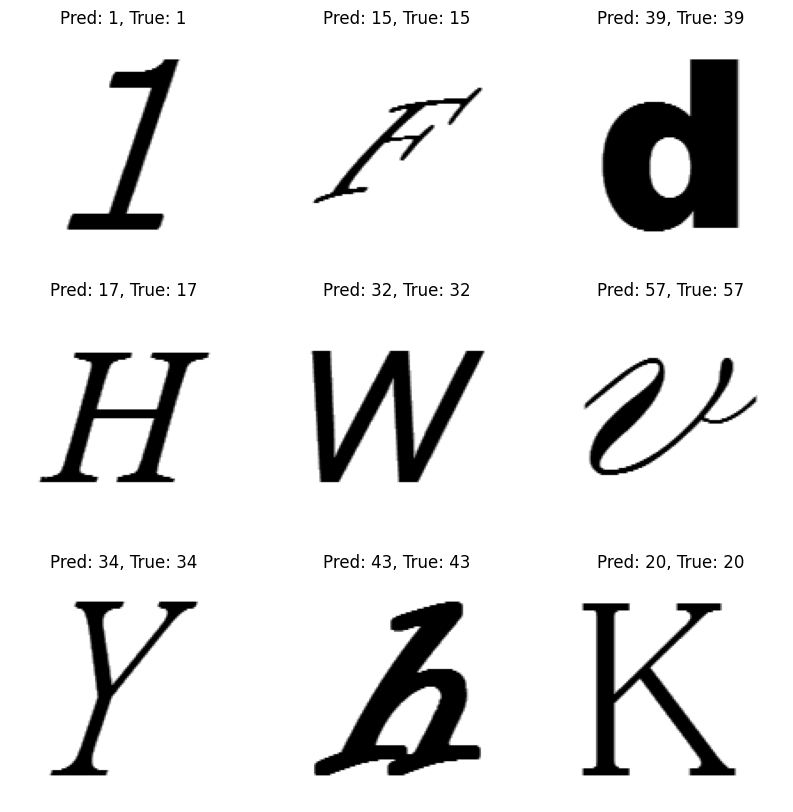

In [ ]:
#evaluate model on holdout dataset
evaluation_metrics = evaluate_model(model, holdout_dataset, configuration)

#display results
print("\n=== Holdout Set Evaluation ===")
for name, value in evaluation_metrics.items():
    print(f"{name}: {value:.4f}")

# visualize some predictions on the holdout set
num_display = 9
for images, labels in holdout_dataset.take(1):
    logits = model.predict(images)
    predictions = tf.argmax(logits, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(num_display):
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap='gray')
        plt.title(f"Pred: {predictions[i].numpy()}, True: {labels[i].numpy()}")
        plt.axis('off')
    plt.show()
